In [1]:
# Data Import
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import yaml
import os, re, gc, json, string, pickle
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from keras.preprocessing.sequence import pad_sequences
import pickle
import seaborn as sns
import plotly.express as px
import io
import cufflinks as cf
cf.go_offline()

# NLP
import nltk
import spacy
nlp = spacy.load("en_core_web_sm")
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat
from wordcloud import WordCloud



# Vectorizers and models
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# For interpretability
import shap

# Topic modelling (LDA and BERTopic)
from sklearn.decomposition import LatentDirichletAllocation as LDA
from bertopic import BERTopic

# Sentence embeddings
from sentence_transformers import SentenceTransformer

# spacy model
nlp = spacy.load("en_core_web_sm", disable=['parser'])  # enable tagger/ner/lemmatizer as needed

# Utilities
analyzer = SentimentIntensityAnalyzer()
sns.set(style="whitegrid")


# Data Ingestion

In [2]:
# load
ted = pd.read_csv("Data/ted_main.csv", low_memory=False)
trans = pd.read_csv("Data/transcripts.csv", low_memory=False)

# Inspect quick head
print(ted.shape, trans.shape)
display(ted.head())
display(trans.head())

(2550, 17) (2467, 2)


,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


,transcript,url
0,Good morning. How are you?(Laughter)It's been ...,https://www.ted.com/talks/ken_robinson_says_sc...
1,"Thank you so much, Chris. And it's truly a gre...",https://www.ted.com/talks/al_gore_on_averting_...
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",https://www.ted.com/talks/david_pogue_says_sim...
3,If you're here today — and I'm very happy that...,https://www.ted.com/talks/majora_carter_s_tale...
4,"About 10 years ago, I took on the task to teac...",https://www.ted.com/talks/hans_rosling_shows_t...


In [3]:
print(ted.shape)
print(trans.shape)

(2550, 17)
(2467, 2)


In [4]:
# Example merge key guesses: 'url', 'slug', or 'title'. Prefer robust keys if available.
# Try merging on 'url' if present in both:
merge_keys = None
for k in ['url', 'slug', 'title', 'talk_id', 'id']:
    if k in ted.columns and k in trans.columns:
        merge_keys = k
        break

if merge_keys:
    df = ted.merge(trans, how='left', on=merge_keys, suffixes=('', '_trans'))
else:
    # fallback: if transcripts have talk titles and urls in a different column, match on cleaned title
    # create cleaned title columns and merge
    def clean_title(s):
        return re.sub(r'\W+', ' ', str(s).lower()).strip()
    ted['title_cl'] = ted.get('title', ted.get('name', '')).apply(clean_title)
    trans['title_cl'] = trans.get('title', trans.get('name', '')).apply(clean_title)
    df = ted.merge(trans, how='left', on='title_cl')
    
print("Merged shape:", df.shape)


Merged shape: (2553, 18)


# Basic Text-Preprocessing before EDA

In [5]:
df.info()
df.isna().sum().sort_values().head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553 entries, 0 to 2552
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comments            2553 non-null   int64 
 1   description         2553 non-null   object
 2   duration            2553 non-null   int64 
 3   event               2553 non-null   object
 4   film_date           2553 non-null   int64 
 5   languages           2553 non-null   int64 
 6   main_speaker        2553 non-null   object
 7   name                2553 non-null   object
 8   num_speaker         2553 non-null   int64 
 9   published_date      2553 non-null   int64 
 10  ratings             2553 non-null   object
 11  related_talks       2553 non-null   object
 12  speaker_occupation  2547 non-null   object
 13  tags                2553 non-null   object
 14  title               2553 non-null   object
 15  url                 2553 non-null   object
 16  views               2553

comments               0
url                    0
title                  0
tags                   0
related_talks          0
ratings                0
published_date         0
views                  0
num_speaker            0
main_speaker           0
languages              0
film_date              0
event                  0
duration               0
description            0
name                   0
speaker_occupation     6
transcript            86
dtype: int64

In [6]:
#Convert Datetimes
for col in ['film_date', 'published_date', 'date', 'date_added']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


In [7]:
#Numeric casting for views like and 
for c in ['views','comments','likes','ratings','num_speaker_talks']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


In [8]:
# Basic Text Fields
# choose transcript column name in your CSV; adjust if different
if 'transcript' not in df.columns:
    # check common names
    for c in ['transcripts','text','content','body']:
        if c in df.columns:
            df.rename(columns={c: 'transcript'}, inplace=True)
            break

df['transcript'] = df['transcript'].fillna('').astype(str)
df['description'] = df.get('description', '').fillna('').astype(str)
df['title'] = df.get('title', df.get('name', '')).astype(str)


# EDA

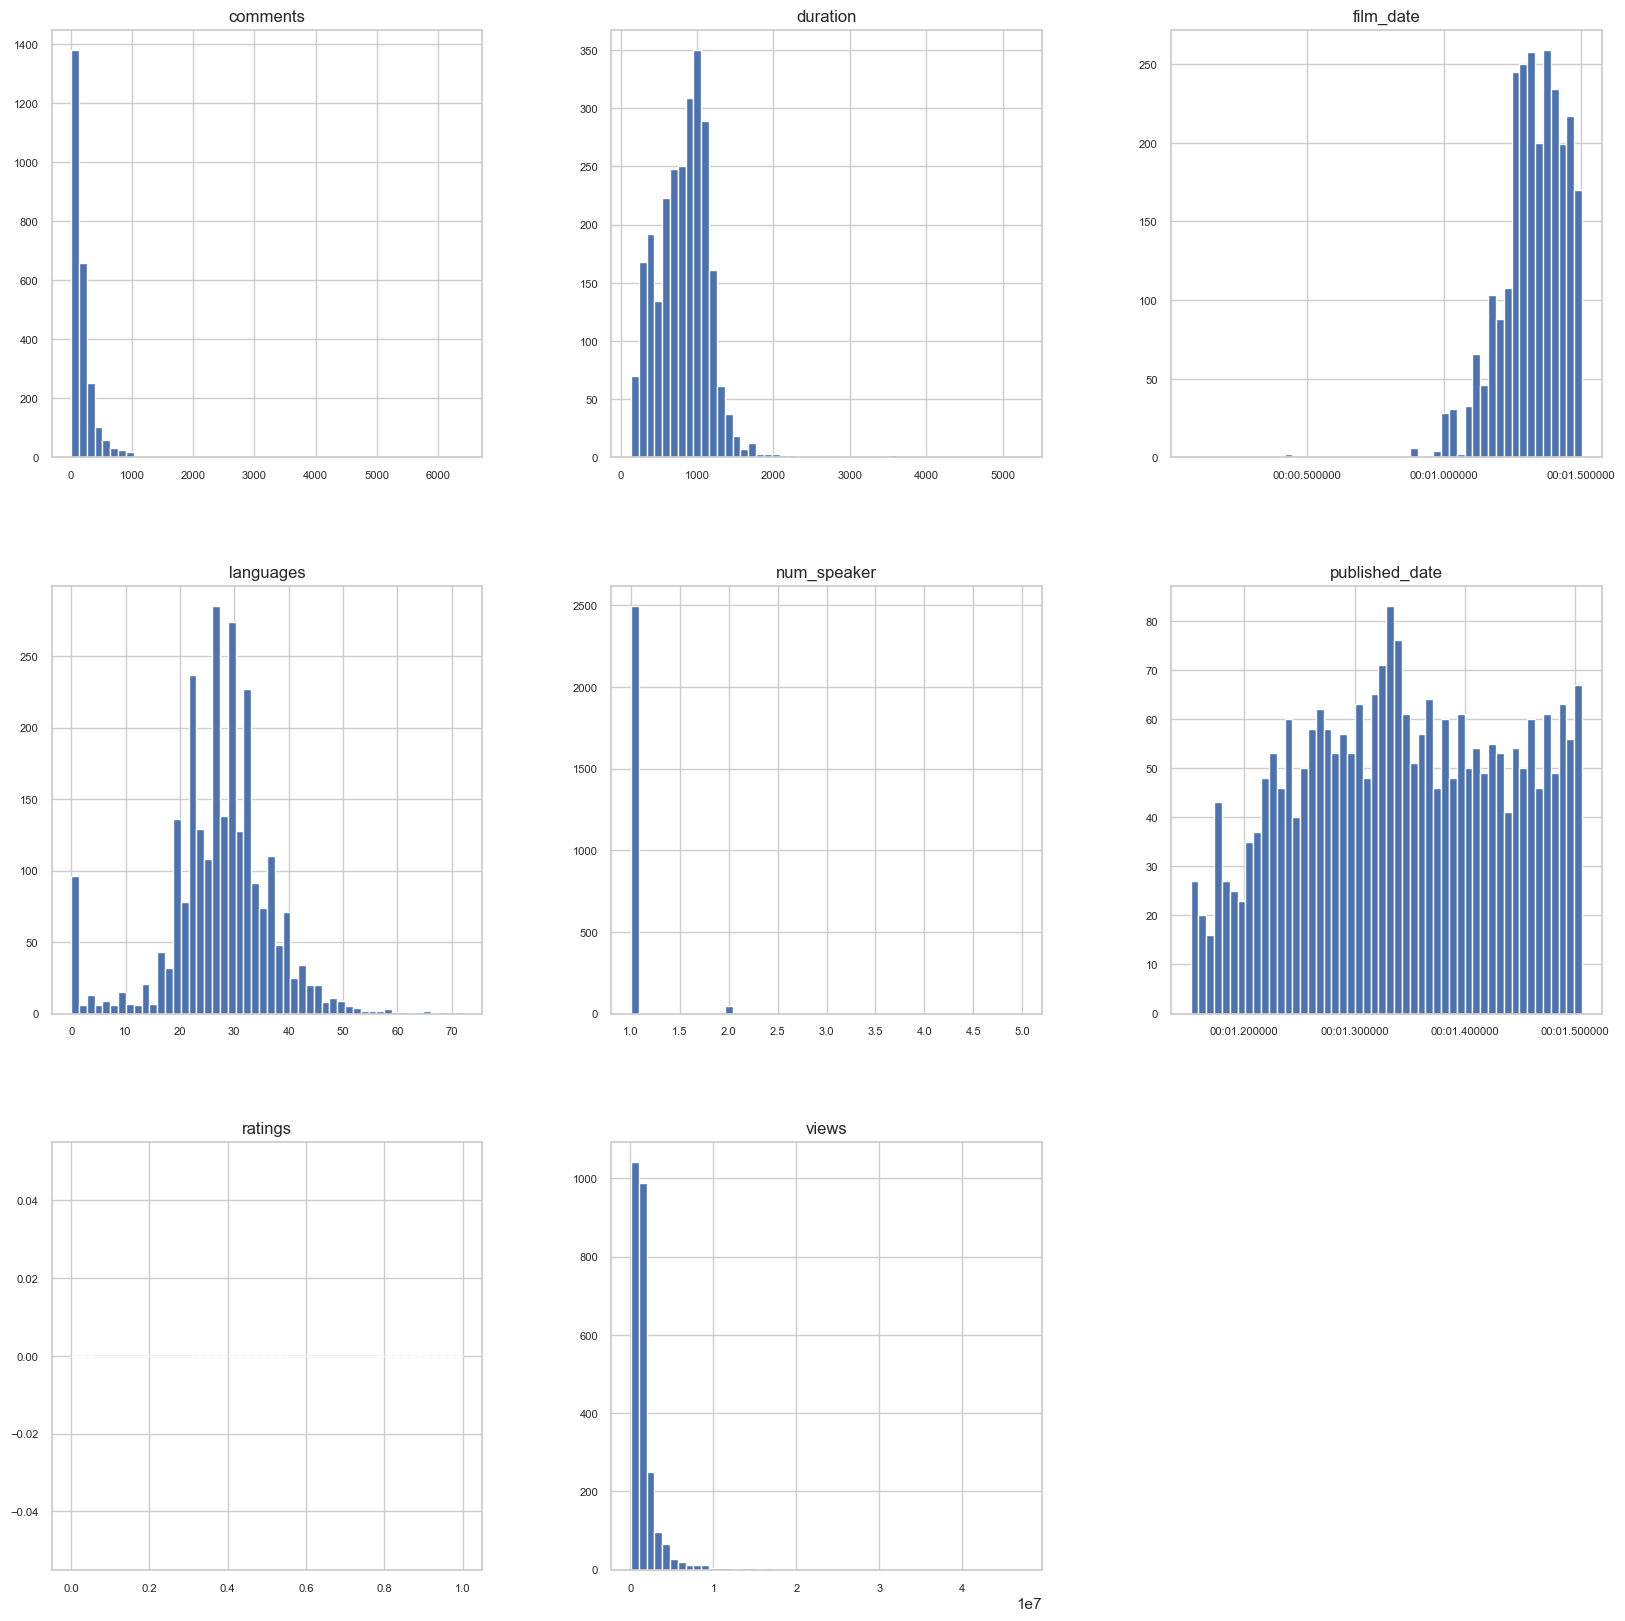

In [9]:
df.hist(figsize=(20, 20), bins=50, xlabelsize=8, ylabelsize=8); 

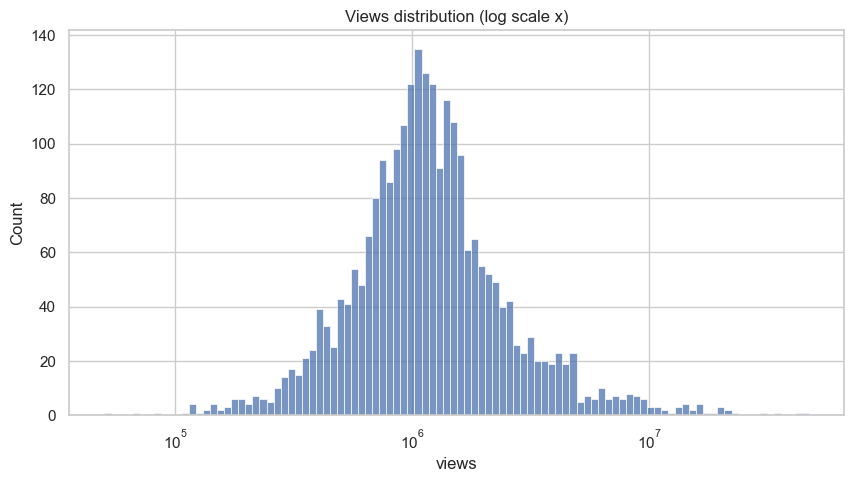

In [10]:
# Views distribution
plt.figure(figsize=(10,5))
sns.histplot(df['views'].dropna(), bins=100, log_scale=(True, False))
plt.title("Views distribution (log scale x)")
plt.show()


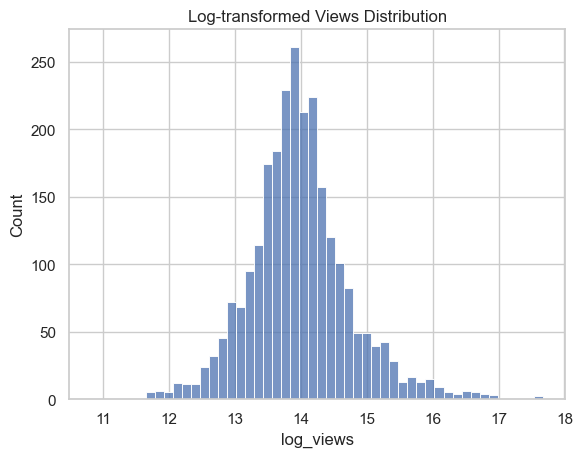

In [11]:
import numpy as np

df['log_views'] = np.log1p(df['views'])  # log(views + 1)
sns.histplot(df['log_views'].dropna(), bins=50)
plt.title("Log-transformed Views Distribution")
plt.show()

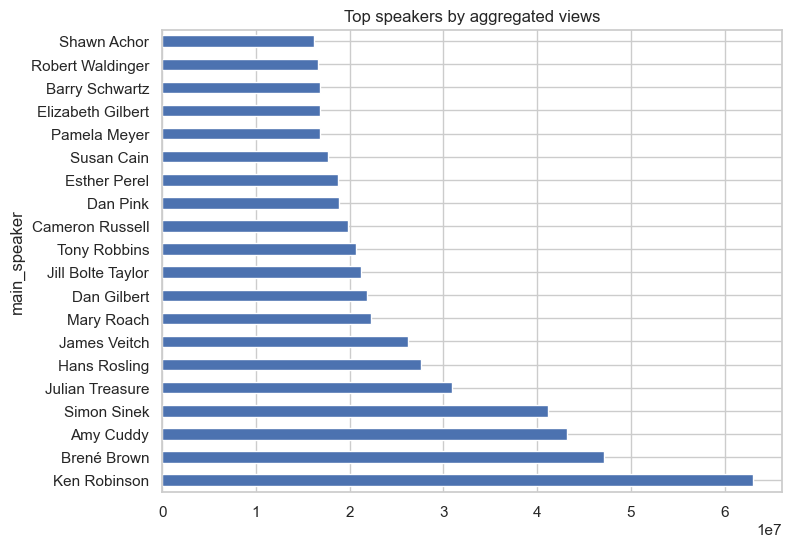

In [12]:
# top speakers by total views
top_speakers = df.groupby('main_speaker')['views'].sum().sort_values(ascending=False).head(20)
top_speakers.plot(kind='barh', figsize=(8,6))
plt.title("Top speakers by aggregated views")
plt.show()

In [13]:
# Missing per column
missing = (df.isna().sum()/len(df)).sort_values(ascending=False)
missing.head(30)


ratings               1.00000
speaker_occupation    0.00235
comments              0.00000
transcript            0.00000
views                 0.00000
url                   0.00000
title                 0.00000
tags                  0.00000
related_talks         0.00000
published_date        0.00000
description           0.00000
num_speaker           0.00000
name                  0.00000
main_speaker          0.00000
languages             0.00000
film_date             0.00000
event                 0.00000
duration              0.00000
log_views             0.00000
dtype: float64

In [14]:
views = df.sort_values(by = 'views', ascending = False).head(10).reset_index()
fig = px.bar_polar(views, 
                   r="duration", 
                   theta="title", 
                   color="views",
                   color_discrete_sequence= px.colors.sequential.Plasma_r,
                   title="top 10 talks, number of views and duration"
                  )
fig.show(renderer="browser")



In [15]:
# Top 10 ted talks events
# group the data by the event and calculate the sum
sums=df.groupby("event")["views"].agg(["sum","mean","count"]).sort_values("sum",ascending=False) .nlargest(10,"sum")
text=(sums["mean"]/1000000).round(2).astype(str)+" M"
fig=px.bar(sums,x=sums.index,y="mean",
           labels={"y":"Sum & mean & number of talks","x":"event"},
      title="Average number of views for event",
       color_discrete_sequence=["#154360"],
           text=text 
      )
fig.update_layout(
title_font_color="#fff",paper_bgcolor="#283747",title_font_size=20,title_x=.5,font_color="#bbb",
    plot_bgcolor="#D0D3D4")
fig.update_yaxes(showgrid=False,visible=False,title="percent of commencts")
fig.update_xaxes(tickfont_size=9,color="#fff")
fig.show(renderer="browser")


In [16]:
text=(sums["sum"]/1000000).round(1).astype(str)+" M"
fig=px.bar(sums,x=sums.index,y="sum",
           labels={"y":"Sum & mean & number of talks","x":"event"},
      title="Total number of views for event",
       color_discrete_sequence=["#154360"],
           text=text 
      )
fig.update_layout(
title_font_color="#fff",paper_bgcolor="#283747",title_font_size=20,title_x=.5,font_color="#bbb",
    plot_bgcolor="#D0D3D4")
fig.update_yaxes(showgrid=False,visible=False,title="percent of commencts")
fig.update_xaxes(tickfont_size=9,color="#fff")
fig.show(renderer="browser")

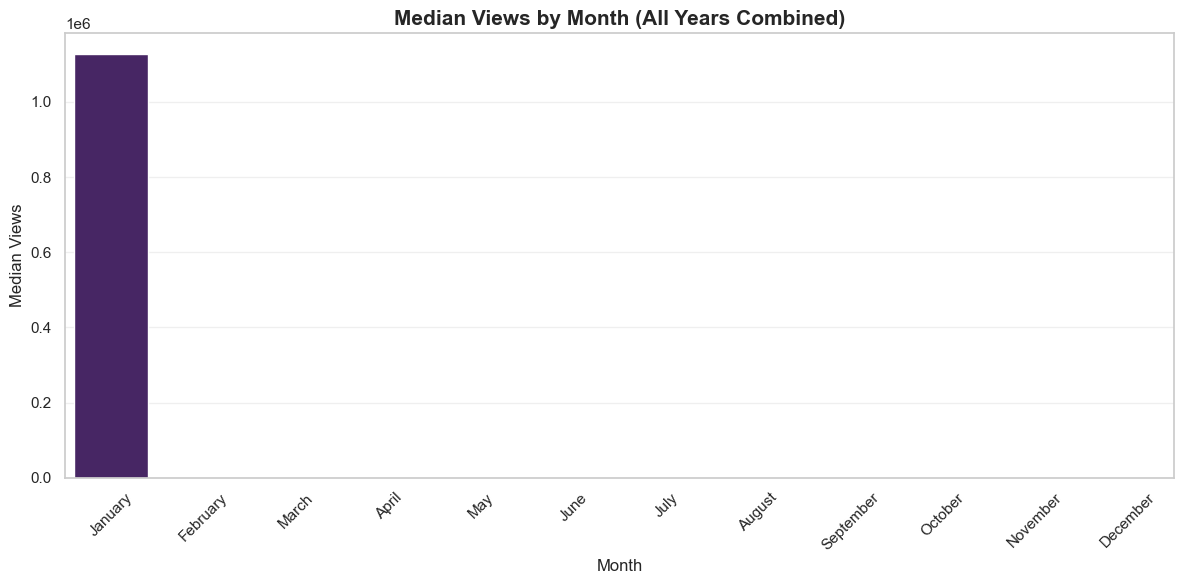

In [17]:
# Monthly views> Temporal trends
if 'published_date' in df.columns and 'views' in df.columns:
    df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
    df = df.dropna(subset=['published_date', 'views'])

    # Extract month names
    df['month'] = df['published_date'].dt.month_name()

    # Aggregate median views per month (across all years)
    monthly = df.groupby('month')['views'].median()

    # Ensure months appear in calendar order
    order = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    monthly = monthly.reindex(order)

    # Plot
    plt.figure(figsize=(12,6))
    sns.barplot(x=monthly.index, y=monthly.values, palette="viridis")
    plt.title("Median Views by Month (All Years Combined)", fontsize=15, weight='bold')
    plt.xticks(rotation=45)
    plt.ylabel("Median Views")
    plt.xlabel("Month")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [18]:
# Text Statistics per talk
# Create features: transcript_len_chars, transcript_len_words, avg_word_len, unique_word_ratio, num_sentences, lexical_diversity.
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize, sent_tokenize

def text_stats(t):
    t = str(t)
    words = word_tokenize(t)
    sents = sent_tokenize(t)
    wc = len(words)
    uc = len(set([w.lower() for w in words]))
    return pd.Series({
        'len_chars': len(t),
        'len_words': wc,
        'len_sents': len(sents),
        'unique_word_ratio': uc / max(wc,1),
        'avg_word_len': np.mean([len(w) for w in words]) if wc>0 else 0
    })

text_features = df['transcript'].apply(text_stats)
df = pd.concat([df, text_features], axis=1)
df[['len_words','len_sents','unique_word_ratio']].describe()


[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,len_words,len_sents,unique_word_ratio
count,2553.000000,2553.000000,2553.000000
mean,2326.109675,109.556208,0.276806
std,1195.879960,62.121153,0.085015
min,0.000000,0.000000,0.000000
25%,1457.000000,64.000000,0.234553
50%,2331.000000,104.000000,0.272616
75%,3168.000000,147.000000,0.319126
max,10657.000000,488.000000,0.671429


In [19]:
# Sentiments and readability
# Higher Flesch score = easier reading. VADER gives a coarse polarity — can be useful feature.
analyzer = SentimentIntensityAnalyzer()
df['vader_compound'] = df['transcript'].apply(lambda t: analyzer.polarity_scores(t)['compound'])
df['flesch_reading'] = df['transcript'].apply(lambda t: textstat.flesch_reading_ease(t) if len(t)>20 else np.nan)


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

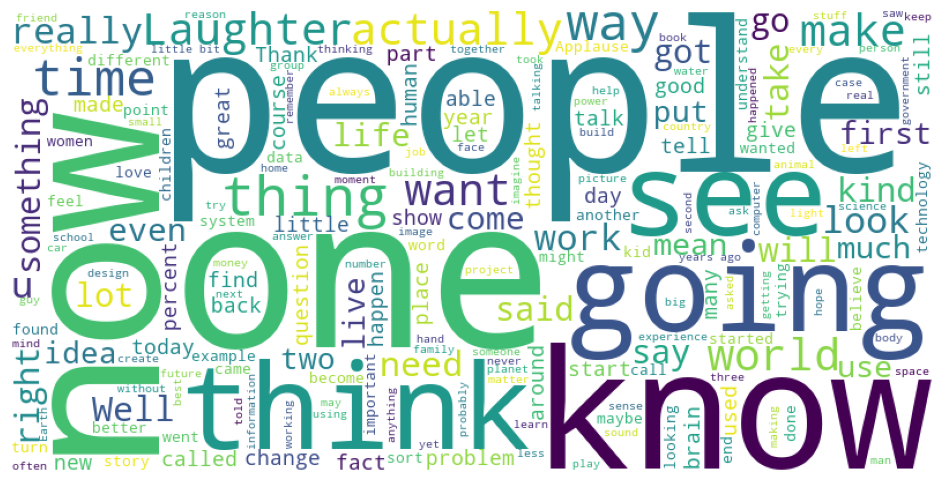

In [20]:
# Word clouds / frequent n-grams & topics (preview)
all_text = " ".join(df['transcript'].values)
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(12,6)); plt.imshow(wc); plt.axis('off')


In [21]:
# for n-grams
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(1,2), max_features=2000, stop_words='english')
Xcv = cv.fit_transform(df['transcript'])
freq = np.array(Xcv.sum(axis=0)).ravel()
top_idx = np.argsort(freq)[-30:][::-1]
[(cv.get_feature_names_out()[i], freq[i]) for i in top_idx]


[('people', np.int64(19734)),
 ('like', np.int64(19203)),
 ('just', np.int64(16192)),
 ('know', np.int64(13017)),
 ('going', np.int64(12880)),
 ('think', np.int64(12124)),
 ('really', np.int64(11046)),
 ('ve', np.int64(10692)),
 ('time', np.int64(10540)),
 ('laughter', np.int64(10353)),
 ('world', np.int64(10350)),
 ('don', np.int64(9607)),
 ('way', np.int64(9047)),
 ('actually', np.int64(8894)),
 ('years', np.int64(8753)),
 ('things', np.int64(8585)),
 ('want', np.int64(8222)),
 ('make', np.int64(7963)),
 ('right', np.int64(7687)),
 ('said', np.int64(7223)),
 ('new', np.int64(6558)),
 ('look', np.int64(6544)),
 ('thing', np.int64(6289)),
 ('little', np.int64(6223)),
 ('life', np.int64(6181)),
 ('got', np.int64(6163)),
 ('say', np.int64(6116)),
 ('work', np.int64(6056)),
 ('need', np.int64(5836)),
 ('applause', np.int64(5539))]

In [22]:
# Top preview with 
tf = TfidfVectorizer(max_features=20000, stop_words='english')
Xtf = tf.fit_transform(df['transcript'])
lda = LDA(n_components=10, random_state=42)
lda.fit(Xtf)  # or use CountVectorizer matrix
def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        print("Topic %d:" % (topic_idx), " ".join(top_features))

print_topics(lda, tf.get_feature_names_out(), 10)


Topic 0: people like just going know laughter think really world ve
Topic 1: higgs lhc rb pms edi fonio amyloid boson td tapirs
Topic 2: music applause marshmallow billie jh aed vultures 404 derek beatboxing
Topic 3: littlebits chk mola benki hurdy gurdy humanae visicalc navid zodiac
Topic 4: mk guerrillas rezero givers crows bf netra carousel gabby itjtawy
Topic 5: heh whitopia sweeney cmu veronica nollywood gwen todai oiled nico
Topic 6: bj abed rw lg everglades symmetries cyrus tembererana atrazine movember
Topic 7: ja clonie quad asl fibonacci teszler ranger im rng esg
Topic 8: fbi asteroids autistic marijuana kepler neocortex isis titan bitcoin spacecraft
Topic 9: yr js protocell mycelium cybercriminals fn catadores bonica abalone doaa


# Text cleaning & advanced preprocessing (in detail)

Goals: standardized tokens, meaningful lemmatization, preserving negation & named entities where useful.

In [24]:
# Stopwords and contraction normalization
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# optional - extend stopwords with TED-specific tokens
ted_stop = set(['applause','laughs','laugh','audience'])
stop_words |= ted_stop


[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# Cleaner function (remove URLs, bracketed timestamps, repeated chars)
url_re = re.compile(r'https?://\S+|www\.\S+')
brackets = re.compile(r'\[.*?\]|\(.*?\)')
multi_space = re.compile(r'\s+')
repeat = re.compile(r'(.)\1{2,}')  # char repeated 3+ times

def clean_text(text):
    text = str(text)
    text = url_re.sub(' ', text)
    text = brackets.sub(' ', text)
    text = repeat.sub(r'\1', text)
    text = re.sub(r'[^A-Za-z0-9\'\s\-]', ' ', text)  # keep apostrophes & hyphens
    text = multi_space.sub(' ', text)
    return text.strip().lower()

df['transcript_clean'] = df['transcript'].apply(clean_text)


In [26]:
'''
Lemmatization with spaCy (preserve adjectives/nouns, remove pronouns optionally)

Using spaCy for lemmatization preserves better contextual lemmas than naive NLTK stemmers.
'''
# Use spaCy pipeline but disable parser for speed; enable tagger and lemmatizer
nlp = spacy.load("en_core_web_sm", disable=['parser','ner'])
def lemmatize_text(doc):
    doc = nlp(doc)
    tokens = []
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue
        lemma = tok.lemma_.lower()
        # drop stopwords, numbers (optionally)
        if lemma in stop_words:
            continue
        if lemma.isnumeric():
            continue
        # optional: remove pronouns like -PRON-
        if lemma == '-pron-':
            continue
        tokens.append(lemma)
    return " ".join(tokens)

# Apply with progress (use tqdm if many rows)
from tqdm import tqdm
tqdm.pandas()
df['transcript_lemma'] = df['transcript_clean'].progress_map(lemmatize_text)


100%|██████████| 2553/2553 [03:42<00:00, 11.49it/s]


In [27]:
# POS counts and Named entity counts
def pos_ner_counts(text):
    doc = nlp(text)
    pos_counts = {}
    for p in ['NOUN','VERB','ADJ','ADV','PROPN']:
        pos_counts[f'pos_{p.lower()}'] = sum(1 for t in doc if t.pos_==p)
    pos_counts['num_ents'] = len(doc.ents)
    return pd.Series(pos_counts)

pos_feats = df['transcript_clean'].progress_map(pos_ner_counts)
df = pd.concat([df, pos_feats], axis=1)


100%|██████████| 2553/2553 [03:40<00:00, 11.60it/s]


# Feature engineering (text + metadata)

Create a feature set that combines:

Tabular metadata: film_year, duration, language, event, speaker_experience (count of talks by speaker)

Text features: TF-IDF vectors, sentence embeddings (mean pooling), topic probabilities, sentiment, readability, POS counts

Interaction features: len_words * flesch_reading, vader_compound * unique_word_ratio

In [30]:
# Speaker Experience
if 'speaker' in df.columns:
    df['speaker_talk_count'] = df.groupby('speaker')['title'].transform('count')


In [31]:
# TF-IDF sparse
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=5, stop_words='english')
X_tfidf = tfidf.fit_transform(df['transcript_lemma'])


In [ ]:

sbert = SentenceTransformer('all-MiniLM-L6-v2')  # good general model
embeddings = sbert.encode(df['transcript'].tolist(), show_progress_bar=True, batch_size=16)
# embeddings is (n, dim) numpy array

# Note: embeddings are powerful features for BERTopic and downstream models (you can reduce dimensionality with PCA/UMAP

Batches:   0%|          | 0/160 [00:00<?, ?it/s]

In [33]:
# UMAP: Reduces high-dimensional embeddings into a lower space to make clustering easier.
# HDBSCAN: Groups similar embeddings into clusters without needing a preset number of topics.
# BERTopic: Combines UMAP + HDBSCAN to extract and label meaningful text topics with keywords.

from umap import UMAP
from hdbscan import HDBSCAN
umap_model = UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

topic_model = BERTopic(umap_model=umap_model, hdbscan_model=hdbscan_model, min_topic_size=20, verbose=True)
topics, probs = topic_model.fit_transform(df['transcript'])
# add topic id and topic probability (if available)
df['topic'] = topics
# get topic frequencies / descriptions
topic_model.get_topic_info().head(20)


2025-10-23 23:11:39,128 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/80 [00:00<?, ?it/s]

2025-10-23 23:11:57,233 - BERTopic - Embedding - Completed ✓
2025-10-23 23:11:57,234 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-23 23:12:04,435 - BERTopic - Dimensionality - Completed ✓
2025-10-23 23:12:04,436 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-23 23:12:04,486 - BERTopic - Cluster - Completed ✓
2025-10-23 23:12:04,488 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 23:12:05,647 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,2467,0_the_and_to_of,"[the, and, to, of, that, in, is, you, we, it]",[I can't help but this wish: to think about wh...
1,1,57,1____,"[, , , , , , , , , ]","[, , ]"
2,2,29,2____,"[, , , , , , , , , ]","[, , ]"


# Target selection and modeling goals

Depending on what you want:

Regression: predict views (use log1p(views) to reduce skew)

Classification: binary classify viral vs non-viral (choose threshold e.g., top 10% views)

Ranking / Recommendation: predict relative popularity, or recommend talks by topic similarity

regression (predict log views) and classification (popular or not).



In [ ]:
# Regression: target
df['log_views'] = np.log1p(df['views'].fillna(0))

# classification: top10% as popular
th = df['views'].quantile(0.9)
df['popular'] = (df['views'] >= th).astype(int)

# Modeling pipelines

I’ll build a robust pipeline that handles the sparse TF-IDF and dense embeddings with tree models (LightGBM/XGBoost). Use cross-validation and GridSearch.

In [37]:
# Prepare feature and split
# Select metadata numeric features
meta_cols = []
for c in ['len_words','len_sents','unique_word_ratio','avg_word_len','vader_compound','flesch_reading','speaker_talk_count']:
    if c in df.columns:
        meta_cols.append(c)

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df.get('popular', None))


In [ ]:
# Regression with LightGBM using embeddings + meta
# Use embeddings + meta numeric
X_train_emb = np.hstack([np.array(embeddings)[train_df.index], train_df[meta_cols].fillna(0).values])
X_test_emb = np.hstack([np.array(embeddings)[test_df.index], test_df[meta_cols].fillna(0).values])
y_train = train_df['log_views'].values
y_test = test_df['log_views'].values

lgb_train = lgb.Dataset(X_train_emb, label=y_train)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_freq': 5,
    'bagging_fraction': 0.8,
    'seed': 42
}

model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
)




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99393
[LightGBM] [Info] Number of data points in the train set: 2042, number of used features: 390
[LightGBM] [Info] Start training from score 13.969403
[50]	train's rmse: 0.453915
[100]	train's rmse: 0.314702
[150]	train's rmse: 0.239618
[200]	train's rmse: 0.199817
[250]	train's rmse: 0.178983
[300]	train's rmse: 0.16877
[350]	train's rmse: 0.164388
[400]	train's rmse: 0.16184
[450]	train's rmse: 0.160777
[500]	train's rmse: 0.160293
[550]	train's rmse: 0.160079
[600]	train's rmse: 0.159969
[650]	train's rmse: 0.159938
[700]	train's rmse: 0.159991
[750]	train's rmse: 0.159881
[800]	train's rmse: 0.159895
[850]	train's rmse: 0.159867
[900]	train's rmse: 0.159911
[950]	train's rmse: 0.159849
[1000]	train's rmse: 0.159854


In [45]:
# Predict
preds = model_lgb.predict(X_test_emb, num_iteration=model_lgb.best_iteration)
from sklearn.metrics import mean_squared_error, r2_score
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

RMSE: 0.7507952139213472
R2: 0.0986581418465996


In [50]:
import xgboost
print(xgboost.__version__)


3.1.1


In [56]:
# Classification with TF-IDF + meta + XGBoost: Because TF-IDF is sparse, combine with dense meta using hstack:
from scipy.sparse import hstack

X_tfidf_train = tfidf.transform(train_df['transcript_lemma'])
X_tfidf_test  = tfidf.transform(test_df['transcript_lemma'])
meta_train = train_df[meta_cols].fillna(0).values
meta_test = test_df[meta_cols].fillna(0).values

# Stack sparse + dense (dense -> sparse)
from scipy import sparse
import xgboost as xgb
from xgboost.callback import EarlyStopping  # <-- important
X_train_comb = hstack([X_tfidf_train, sparse.csr_matrix(meta_train)])
X_test_comb  = hstack([X_tfidf_test, sparse.csr_matrix(meta_test)])
y_train_cl = train_df['popular'].values
y_test_cl  = test_df['popular'].values


xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Fit with early stopping (3.1.1 compatible)
xgb_clf.fit(
    X_train_comb,
    y_train_cl,
    eval_set=[(X_test_comb, y_test_cl)],
)


[0]	validation_0-logloss:0.32312
[1]	validation_0-logloss:0.31937
[2]	validation_0-logloss:0.31774
[3]	validation_0-logloss:0.31678
[4]	validation_0-logloss:0.31609
[5]	validation_0-logloss:0.31827
[6]	validation_0-logloss:0.31693
[7]	validation_0-logloss:0.31657
[8]	validation_0-logloss:0.31586
[9]	validation_0-logloss:0.31563
[10]	validation_0-logloss:0.31597
[11]	validation_0-logloss:0.31659
[12]	validation_0-logloss:0.31707
[13]	validation_0-logloss:0.31657
[14]	validation_0-logloss:0.31561
[15]	validation_0-logloss:0.31499
[16]	validation_0-logloss:0.31369
[17]	validation_0-logloss:0.31384
[18]	validation_0-logloss:0.31495
[19]	validation_0-logloss:0.31417
[20]	validation_0-logloss:0.31579
[21]	validation_0-logloss:0.31587
[22]	validation_0-logloss:0.31554
[23]	validation_0-logloss:0.31560
[24]	validation_0-logloss:0.31524
[25]	validation_0-logloss:0.31478
[26]	validation_0-logloss:0.31472
[27]	validation_0-logloss:0.31390
[28]	validation_0-logloss:0.31365
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [57]:
from sklearn.metrics import classification_report, roc_auc_score
yprob = xgb_clf.predict_proba(X_test_comb)[:,1]
print("AUC:", roc_auc_score(y_test_cl, yprob))
print(classification_report(y_test_cl, xgb_clf.predict(X_test_comb)))

AUC: 0.6720801364023871
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       460
           1       0.00      0.00      0.00        51

    accuracy                           0.90       511
   macro avg       0.45      0.50      0.47       511
weighted avg       0.81      0.90      0.85       511



# Model Tuning and Finetuning
Use nested CV for honest model selection when hyperparameter tuning.

For time-aware modeling (if predicting views over time), use time series split by film/publish date.

In [55]:
from sklearn.model_selection import StratifiedKFold
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [6, 12],
    'min_samples_leaf': [1, 3]
}
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(rfc, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=2)
gs.fit(X_train_comb, y_train_cl)
print("Best params:", gs.best_params_)
print("Best CV AUC:", gs.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=500; total time=   1.5s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=500; total time=   1.5s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=500; total time=   1.5s
[CV] END ..max_depth=6, min_samples_leaf=3, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=500; total time=   1.6s
[CV] END ..max_depth=6, min_samples_leaf=3, n_estimators=200; total time=   0.8s
[CV] END ..max_depth=6, min_samples_leaf=1, n_estimators=500; total time=   1.6s
[CV] END ..max_depth=6, min_

# 10 — Model interpretation (SHAP)

Use SHAP to understand feature importance (for dense models). For sparse TF-IDF models, get feature names from TF-IDF to inspect important tokens.

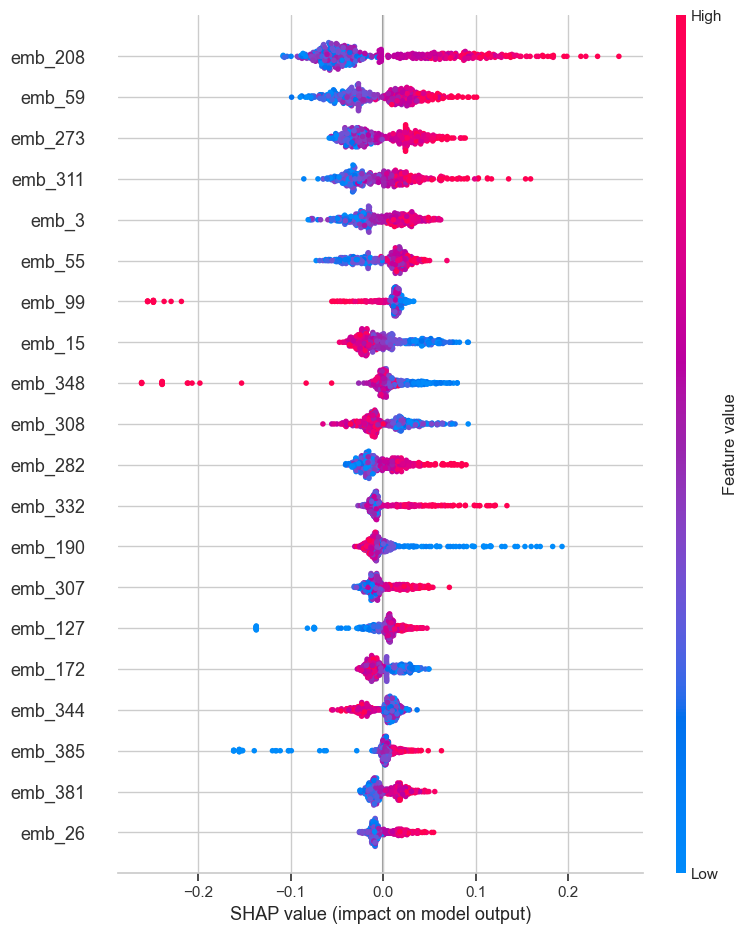

In [58]:
# SHAP for LightGBM regression
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer(X_test_emb)
# Summary plot
shap.summary_plot(shap_values, features=X_test_emb, feature_names=[f'emb_{i}' for i in range(X_test_emb.shape[1])])

In [ ]:
# For TF-IDF + XGBoost:

# Extract top TF-IDF features by average SHAP value or XGBoost feature importance (feat indices map to tfidf.get_feature_names_out() + meta_cols).

# Map feature indices to names for XGBoost model
tfidf_features = list(tfidf.get_feature_names_out())
feature_names = tfidf_features + meta_cols
# Use shap on xgb_clf (may be heavy)
import shap

# Use booster directly
explainer = shap.TreeExplainer(xgb_clf.g)

# For sparse matrix convert to dense sample subset
X_sample = X_train_comb[:500].toarray()
shap_vals = explainer.shap_values(X_sample)
shap.summary_plot(shap_vals, X_sample, feature_names=feature_names)

In [71]:
import shap
print(shap.__version__)

0.49.1


In [70]:
pip install --upgrade shap


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [69]:
pip install xgboost==1.6.2


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.0 MB/s  0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.1
    Uninstalling xgboost-3.1.1:
      Successfully uninstalled xgboost-3.1.1
Note: you may need to restart the kernel to use updated packages.
